<a href="https://colab.research.google.com/github/MuhammadAqsandy/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 – Classification

## 📖 Summary
Chapter 5 introduces **classification** — predicting which *category* an observation belongs to. Unlike regression (predicting a number), classification outputs a discrete class label.

### Key Topics Covered:
1. **Naive Bayes** – probabilistic classifier using Bayes' theorem
2. **Discriminant Analysis (LDA/QDA)** – projection-based classifiers
3. **Logistic Regression** – S-shaped probability model
4. **Evaluating Classification** – confusion matrix, precision, recall, ROC-AUC
5. **Strategies for Imbalanced Data** – oversampling, class weights
6. **K-Nearest Neighbors (KNN)**


## 1. Setup & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

# Breast cancer dataset
data = load_breast_cancer(as_frame=True)
X = data.data[['mean radius','mean texture','mean perimeter','mean area',
               'mean smoothness','mean concavity']].copy()
y = data.target  # 1=benign, 0=malignant

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class balance: {y.value_counts().to_dict()}")


Dataset: 569 samples, 6 features
Class balance: {1: 357, 0: 212}


## 2. Naive Bayes

In [2]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)
y_pred_nb = nb.predict(X_test_s)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['Malignant','Benign']))


=== Naive Bayes ===
              precision    recall  f1-score   support

   Malignant       0.90      0.86      0.88        42
      Benign       0.92      0.94      0.93        72

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



### 📚 Theory: Naive Bayes
Uses **Bayes' theorem** with the "naive" assumption that features are **conditionally independent** given the class:

$$P(C|x_1,...,x_n) \propto P(C) \prod_{i=1}^{n} P(x_i|C)$$

- **Prior** $P(C)$ = class frequency in training data
- **Likelihood** $P(x_i|C)$ = feature distribution per class
- Despite the naive independence assumption, it works surprisingly well in practice.


## 3. Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

   Malignant       0.81      0.93      0.87        42
      Benign       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



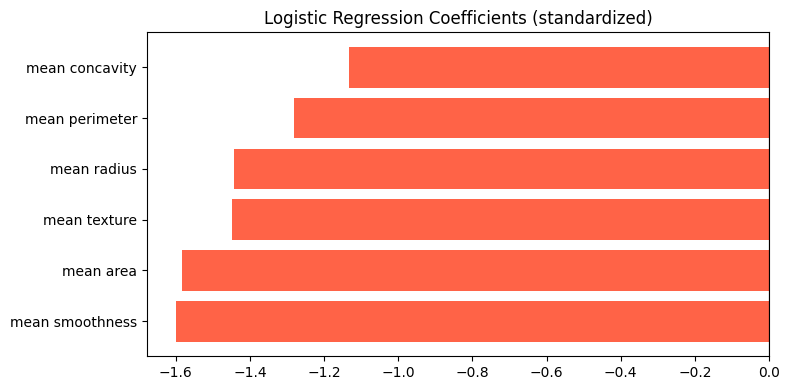

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr  = lr.predict_proba(X_test_s)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Malignant','Benign']))

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (standardized)')
plt.tight_layout()
plt.savefig('ch5_lr_coef.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Logistic Regression
Models the **log-odds** (logit) as a linear combination of features:

$$\log \frac{p}{1-p} = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$

The **sigmoid function** converts log-odds to probability:
$$p = \frac{1}{1 + e^{-z}}$$

- Coefficients represent change in log-odds per unit increase in that feature.
- A positive coefficient → higher probability of class 1.
- Trained via **maximum likelihood estimation** (MLE).


## 4. ROC Curve & AUC

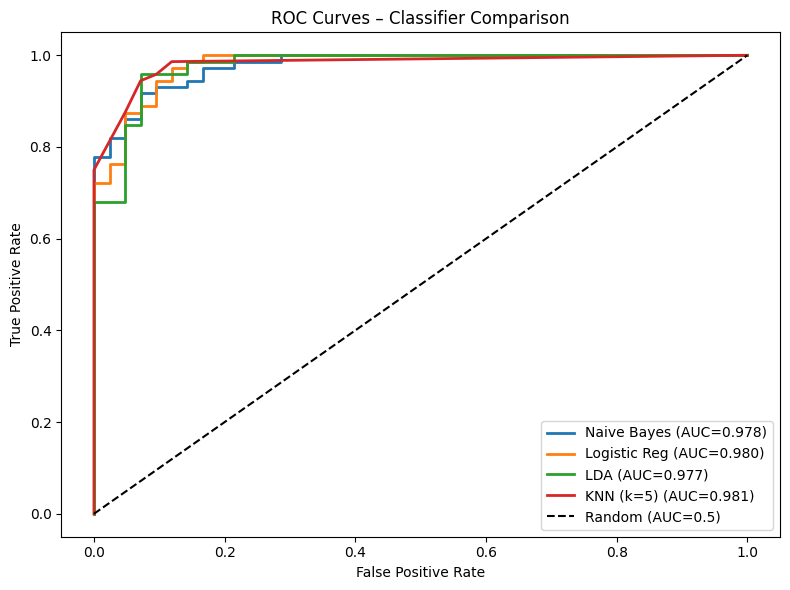

In [4]:
models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Reg': LogisticRegression(max_iter=1000),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    model.fit(X_train_s, y_train)
    prob = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Classifier Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('ch5_roc.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Confusion Matrix

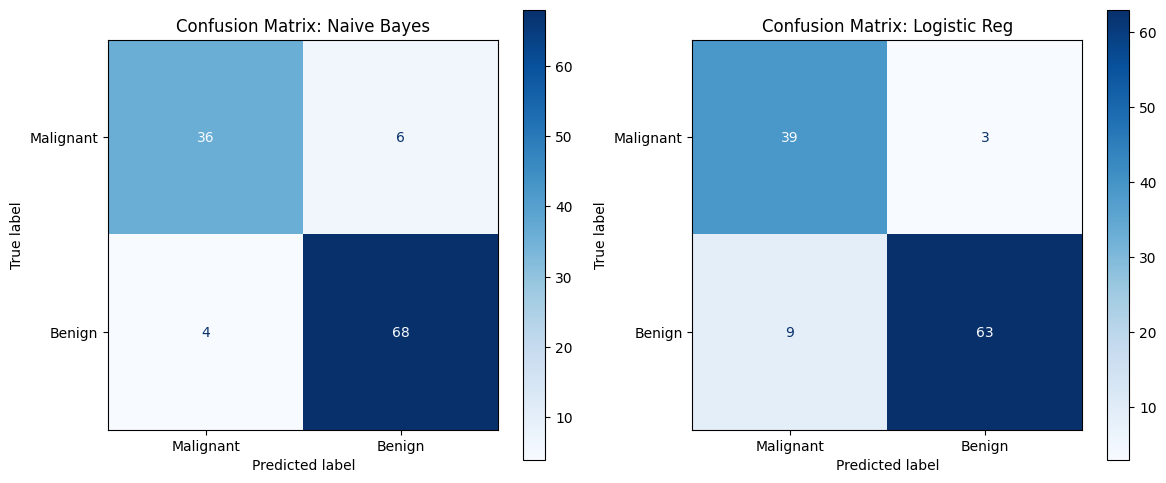

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, list(models.items())[:2]):
    y_p = model.predict(X_test_s)
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=['Malignant','Benign']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}')
plt.tight_layout()
plt.savefig('ch5_confusion.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Evaluation Metrics

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |

- **Precision** = TP / (TP + FP) — of predicted positives, how many are correct?
- **Recall** = TP / (TP + FN) — of actual positives, how many did we catch?
- **F1** = harmonic mean of Precision and Recall
- **AUC-ROC** = area under the ROC curve; 0.5 = random, 1.0 = perfect

Choosing between precision and recall depends on the **cost of errors** in the business context.


## ✅ Chapter 5 Summary

| Model | Strengths | Weaknesses |
|---|---|---|
| Naive Bayes | Fast, works with small data | Independence assumption |
| Logistic Regression | Interpretable, probabilistic | Linear decision boundary |
| LDA | Works well with Gaussian features | Assumes equal covariance |
| KNN | Non-parametric, flexible | Slow at inference, sensitive to scale |

Always **scale features** before LR, LDA, and KNN. Use AUC-ROC for imbalanced datasets — accuracy alone is misleading.
